In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from constants import CALCEDatasetConstants
from preprocessing_functions import generate_sliding_window_data
from models import TCN_GRU_DNN_Model, BiLSTM_Attention, abc_algorithm, BiGRUModel, CNN_DBLSTM_Model

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Loading the Data

In [5]:
PROCESSED_BATTERY_PATHS = [CALCEDatasetConstants.BATTERY_PROCESSED_PATH.value / (battery_name+'.csv') for battery_name in CALCEDatasetConstants.BATTERY_NAMES.value]
PROCESSED_BATTERY_PATHS

[WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_35.csv'),
 WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_36.csv'),
 WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_37.csv'),
 WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_38.csv')]

In [6]:
dfs = {CALCEDatasetConstants.BATTERY_NUMBERS.value[i]: \
       pd.read_csv(PROCESSED_BATTERY_PATHS[i]).drop(['Unnamed: 0'], axis=1) for i in range(len(CALCEDatasetConstants.BATTERY_NUMBERS.value))}
dfs

{35:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.123221
 1              2                1.111035
 2              3                1.106058
 3              4                1.102627
 4              5                1.098143
 ..           ...                     ...
 757          758                0.332357
 758          759                0.328566
 759          760                0.325232
 760          761                0.322707
 761          762                0.319955
 
 [762 rows x 2 columns],
 36:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.134613
 1              2                1.124949
 2              3                1.121679
 3              4                1.119217
 4              5                1.115648
 ..           ...                     ...
 768          769                0.173019
 769          770                0.169924
 770          771                0.168700
 771          772                0.168793

# Visualizing the data along with train test split

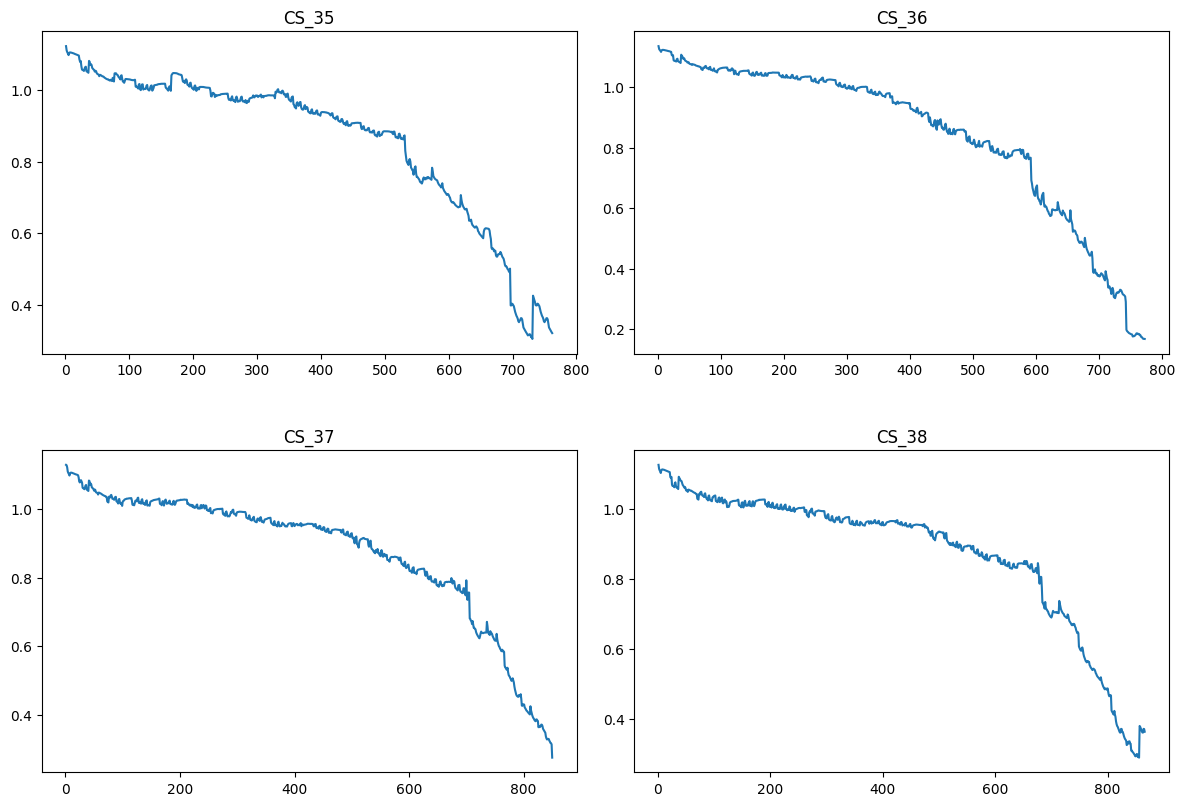

In [7]:
fig, ax = plt.subplots(nrows=int(len(dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(dfs.items()):
    ax[int(i/2), i%2].plot(df['Cycle_Index'], df['Discharge_Capacity(Ah)'])
    ax[int(i/2), i%2].set_title(f'CS_{battery_number}')

plt.show()

In [8]:
TRAINING_BATTERIES = CALCEDatasetConstants.BATTERY_NUMBERS.value[:3]
TEST_BATTERY = CALCEDatasetConstants.BATTERY_NUMBERS.value[3]

In [9]:
x, y = generate_sliding_window_data(dfs[TRAINING_BATTERIES[0]]['Discharge_Capacity(Ah)'])
x.shape, y.shape

((752, 10), (752,))

In [10]:
x.shape, y.shape

((752, 10), (752,))

In [11]:
trainX = []
trainY = []

for battery in TRAINING_BATTERIES:
    x, y = generate_sliding_window_data(dfs[battery]['Discharge_Capacity(Ah)'])
    trainX.extend(x)
    trainY.extend(y)

trainX, trainY = np.array(trainX), np.array(trainY)
trainX.shape, trainY.shape

((2355, 10), (2355,))

In [12]:
testX, testY = generate_sliding_window_data(dfs[TEST_BATTERY]['Discharge_Capacity(Ah)'])
testX, testY = np.array(testX), np.array(testY)
testX.shape, testY.shape

((856, 10), (856,))

In [13]:
class CustomDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        return self.x[idx, :], self.y[idx]

In [14]:
train_dataset = CustomDataset(trainX, trainY)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [15]:
test_dataset = CustomDataset(testX, testY)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [16]:
def train_step(model, x, y, optimizer, criterion, device, min, diff):
    """
    Perform a single training step.

    Args:
        model (torch.nn.Module): The model to train.
        x (torch.Tensor): Input data.
        y (torch.Tensor): Target data.
        optimizer (torch.optim.Optimizer): Optimizer for updating model parameters.
        criterion (torch.nn.Module): Loss function.
        device (torch.device): Device to run the computations on (e.g., 'cpu' or 'cuda').
        min_val (float): Minimum value for normalization.
        diff_val (float): Difference (range) for normalization.

    Returns:
        float: The loss value for the step.
    """
    x = (x - min) / diff
    y = (y - min) / diff

    optimizer.zero_grad()

    predictions = model(x.to(device))
    predictions = predictions.view(-1)

    loss = criterion(predictions, y.to(device))

    loss.backward()
    optimizer.step()

    return loss.item()

def test_step(model, x, y, criterion, device, min, diff):
    """
    Perform a single testing step.

    Args:
        model (torch.nn.Module): The model to evaluate.
        x (torch.Tensor): Input data.
        y (torch.Tensor): Target data.
        criterion (torch.nn.Module): Loss function.
        device (torch.device): Device to run the computations on (e.g., 'cpu' or 'cuda').
        min_val (float): Minimum value for normalization.
        diff_val (float): Difference (range) for normalization.

    Returns:
        float: The loss value for the step.
    """

    x = (x - min) / diff
    y = (y - min) / diff

    model.eval()

    with torch.no_grad():
        predictions = model(x.to(device))
        predictions = predictions.view(-1)

        loss = criterion(predictions, y.to(device))

    return loss.item()


In [17]:
MAX = 1.1
MIN = 0.0
DIFF = MAX - MIN

## TCN-GRU-DNN Model

In [17]:
model_1 = TCN_GRU_DNN_Model().to(device)
optimizer = torch.optim.Adam(model_1.parameters())
criterion = torch.nn.MSELoss()
EPOCHS = 25


for epoch in range(EPOCHS):
    epoch_loss = 0.0
    model_1.train()
    
    for x, y in train_dataloader:
        loss_item = train_step(model_1, x.unsqueeze(1), y, optimizer, criterion, device, MIN, DIFF)
        epoch_loss += loss_item

    avg_loss = epoch_loss / len(train_dataloader)
    if epoch%1 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss}")

C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Epoch 1/25, Loss: 0.15632472695732438
Epoch 2/25, Loss: 0.036134238128323816
Epoch 3/25, Loss: 0.028680583449533663
Epoch 4/25, Loss: 0.011321414746595797
Epoch 5/25, Loss: 0.003125641682197818
Epoch 6/25, Loss: 0.002372801343193026
Epoch 7/25, Loss: 0.0019594587690851374
Epoch 8/25, Loss: 0.0015589353137624425
Epoch 9/25, Loss: 0.0012025188975589903
Epoch 10/25, Loss: 0.0009118430642883066
Epoch 11/25, Loss: 0.0007378971512898224
Epoch 12/25, Loss: 0.0005458925946653393
Epoch 13/25, Loss: 0.0005143692567897331
Epoch 14/25, Loss: 0.0004345236286738057
Epoch 15/25, Loss: 0.00038475474630595763
Epoch 16/25, Loss: 0.0003415039792417775
Epoch 17/25, Loss: 0.00035569436216531823
Epoch 18/25, Loss: 0.0003145157463370344
Epoch 19/25, Loss: 0.00027888001735649397
Epoch 20/25, Loss: 0.000286194316956696
Epoch 21/25, Loss: 0.00025849284581970614
Epoch 22/25, Loss: 0.0002588739055657218
Epoch 23/25, Loss: 0.0002632368856653999
Epoch 24/25, Loss: 0.0002219306633058885
Epoch 25/25, Loss: 0.00023350

In [17]:
model_1.eval()

test_loss = 0.0
criterion = torch.nn.MSELoss(reduction='sum')

with torch.no_grad():
    for x, y in test_dataloader:
        test_loss += test_step(model_1, x.unsqueeze(1), y, criterion, device, MIN, DIFF)

test_loss = np.sqrt(test_loss)
avg_test_loss = test_loss / (len(test_dataloader)*32)
print(len(test_dataloader))

print(f"RMSE: {avg_test_loss:}")

27
RMSE: 0.0004450683186848254


In [18]:
def plot_predictions(
    model, 
    dfs, 
    test_battery, 
    generate_sliding_window_data, 
    min_val, 
    diff_val, 
    device, 
    unsqueeze_dim=1, 
    cutoff_percentage=30
):
    """
    Generates predictions for the test curve using the given model and plots the results.

    Args:
        model (torch.nn.Module): Trained model for predictions.
        dfs (dict): Dictionary containing battery dataframes.
        test_battery (str): Key for the battery data in the dfs dictionary.
        generate_sliding_window_data (callable): Function to generate sliding window data.
        min_val (float): Minimum value used for normalization.
        diff_val (float): Range (difference) used for normalization.
        device (torch.device): Device for computation (e.g., 'cuda' or 'cpu').
        unsqueeze_dim (int, optional): Dimension to unsqueeze before passing to the model. Defaults to 1.
        cutoff_percentage (int, optional): Percentage to determine the cutoff cycle. Defaults to 30.
    
    Returns:
        None
    """
    # Determine cutoff cycle based on percentage
    cutoff_cycle = int(cutoff_percentage * dfs[test_battery].shape[0] / 100)
    
    # Split initial and test curves
    initial = dfs[test_battery].loc[:cutoff_cycle, 'Discharge_Capacity(Ah)'].values
    test_curve = dfs[test_battery].loc[cutoff_cycle:, 'Discharge_Capacity(Ah)'].values

    sliding_windows = generate_sliding_window_data(np.append(initial[-10:], test_curve))[0]

    model.eval()

    with torch.no_grad():
        sliding_windows_scaled = (sliding_windows - min_val) / diff_val

        predictions = model(torch.tensor(sliding_windows_scaled).unsqueeze(unsqueeze_dim).to(device))
        predictions = predictions * diff_val + min_val
        predictions = predictions.flatten()


    cycle_indices = np.arange(1, initial.shape[0] + test_curve.shape[0] + 1)
    cycle_indices_before = cycle_indices[:cutoff_cycle + 1]
    cycle_indices_after = cycle_indices[cutoff_cycle + 1:]

    plt.figure(figsize=(10, 6))
    plt.plot(cycle_indices_before, initial[:cutoff_cycle + 1], label="Initial Data", color="blue")
    plt.plot(cycle_indices_after, test_curve, label="True Test Curve", color="green")
    plt.plot(cycle_indices_after, predictions.cpu(), label="Predictions", color="red", linestyle="--")
    plt.xlabel("Cycle Index")
    plt.ylabel("Discharge Capacity (Ah)")
    plt.title("Predicted vs Actual Discharge Capacity")
    plt.legend()
    plt.grid()
    plt.show()


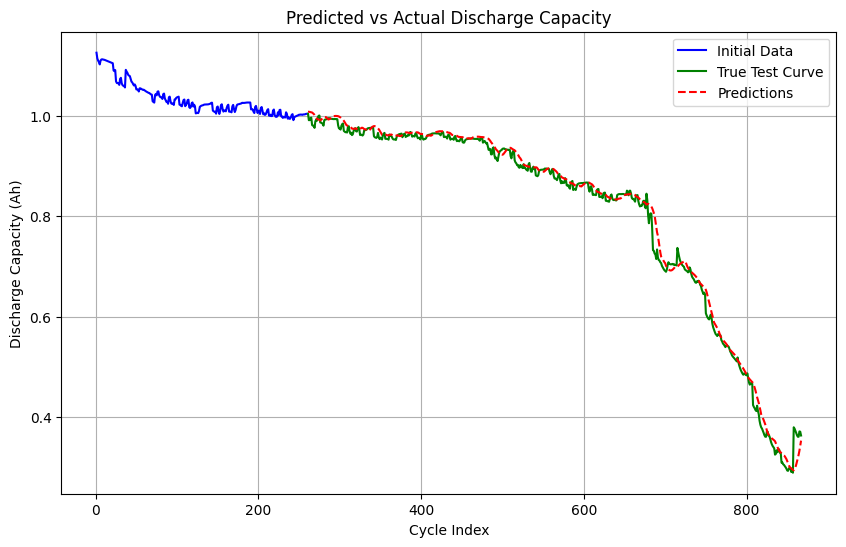

In [20]:
plot_predictions(model_1, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 1, 30)

## BiLSTM Attention Model

In [22]:
model_2 = BiLSTM_Attention(128).to(device)
optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
EPOCHS = 25

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    model_2.train()
    
    for x, y in train_dataloader:
        loss_item = train_step(model_2, x.unsqueeze(-1), y, optimizer, criterion, device, MIN, DIFF)
        epoch_loss += loss_item

    avg_loss = epoch_loss / len(train_dataloader)
    if epoch%1 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss}")

Epoch 1/25, Loss: 0.08961825289234922
Epoch 2/25, Loss: 0.026819253503974225
Epoch 3/25, Loss: 0.0011475275371324372
Epoch 4/25, Loss: 0.000499226828086083
Epoch 5/25, Loss: 0.00036337354420637084
Epoch 6/25, Loss: 0.0003713661122133458
Epoch 7/25, Loss: 0.00018621792603241643
Epoch 8/25, Loss: 0.00028855706738328525
Epoch 9/25, Loss: 0.00028095745324822636
Epoch 10/25, Loss: 0.00020691185420366456
Epoch 11/25, Loss: 0.0003729528213404371
Epoch 12/25, Loss: 0.00029961382844359487
Epoch 13/25, Loss: 0.0013425274398311583
Epoch 14/25, Loss: 0.00022838496851044192
Epoch 15/25, Loss: 0.00026287973889486385
Epoch 16/25, Loss: 0.0002898426086471158
Epoch 17/25, Loss: 0.0003965409171517397
Epoch 18/25, Loss: 0.00035397860758805747
Epoch 19/25, Loss: 0.00027388574961003396
Epoch 20/25, Loss: 0.00018835637323767564
Epoch 21/25, Loss: 0.0002972924875074249
Epoch 22/25, Loss: 0.0004444382565624609
Epoch 23/25, Loss: 0.00042036311272051927
Epoch 24/25, Loss: 0.00019175048274101337
Epoch 25/25, Los

In [26]:
model_2.eval()

test_loss_mse = 0.0
test_loss_mae = 0.0
criterion_1 = torch.nn.MSELoss(reduction='sum')
criterion_2 = torch.nn.L1Loss(reduction='sum')

with torch.no_grad():
    for x, y in test_dataloader:
        test_loss_mse += test_step(model_2, x.unsqueeze(-1), y, criterion_1, device, MIN, DIFF)
        test_loss_mae += test_step(model_2, x.unsqueeze(-1), y, criterion_2, device, MIN, DIFF)

test_loss_mse = np.sqrt(test_loss_mse)
avg_test_loss_mse = test_loss_mse / (len(test_dataloader)*32)
avg_test_loss_mae = test_loss_mae / (len(test_dataloader)*32)
print(len(test_dataloader))

print(f"RMSE: {avg_test_loss_mse:}")
print(f"MAE: {avg_test_loss_mae:}")

27
RMSE: 0.0004689985987542044
MAE: 0.008629839522419152


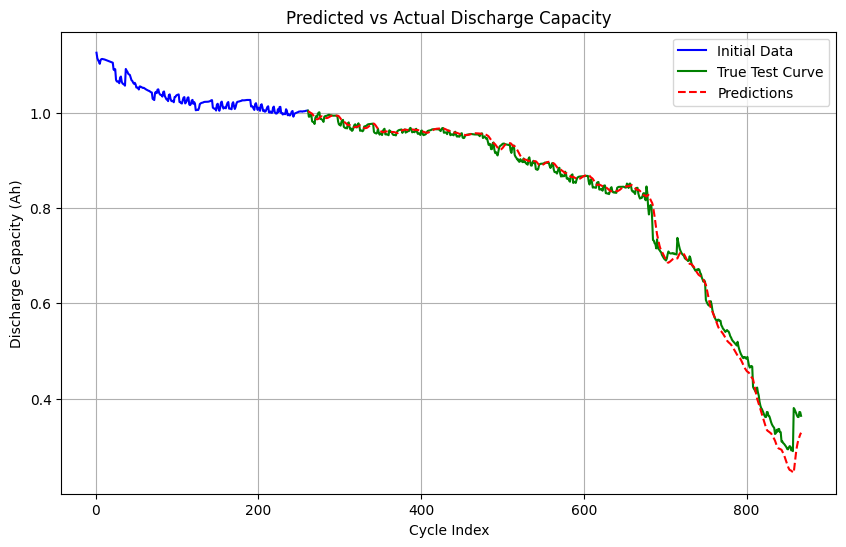

In [27]:
plot_predictions(model_2, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, -1, 30)

## ABC (Artificial Bee Colony) BiGRU Model

In [19]:
bounds = np.array([
    [16, 128],    # Hidden size
    [1e-4, 1e-2], # Learning rate
    [0.1, 0.5]    # Dropout
])

# Run the ABC algorithm with the provided dataloaders
best_params, best_mse = abc_algorithm(bounds, train_dataloader, test_dataloader, n_solutions=10, max_iters=20)
print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

Iteration 1/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 2/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 3/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 4/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 5/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 6/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 7/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 8/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 9/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 10/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 11/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 12/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 13/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 14/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 15/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 16/20, Best Fitness (MSE): 0.00014289461830264405
Iteration 17/20, Best Fitness (MSE): 0.0001428946

In [25]:
model_3 = BiGRUModel(input_size=10, hidden_size=int(round(best_params[0])), dropout=best_params[2]).to(device)
optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
EPOCHS = 10

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    model_3.train()
    
    for x, y in train_dataloader:
        loss_item = train_step(model_3, x.unsqueeze(1), y, optimizer, criterion, device, MIN, DIFF)
        epoch_loss += loss_item

    avg_loss = epoch_loss / len(train_dataloader)
    if epoch%1 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss}")

Epoch 1/10, Loss: 0.06905139596327334
Epoch 2/10, Loss: 0.0029646873700659017
Epoch 3/10, Loss: 0.002384598214317717
Epoch 4/10, Loss: 0.0018698753587700226
Epoch 5/10, Loss: 0.0017293952594234331
Epoch 6/10, Loss: 0.0015450107575570408
Epoch 7/10, Loss: 0.0014806552554128339
Epoch 8/10, Loss: 0.001364861714899087
Epoch 9/10, Loss: 0.001235833124106599
Epoch 10/10, Loss: 0.0013137839945360414


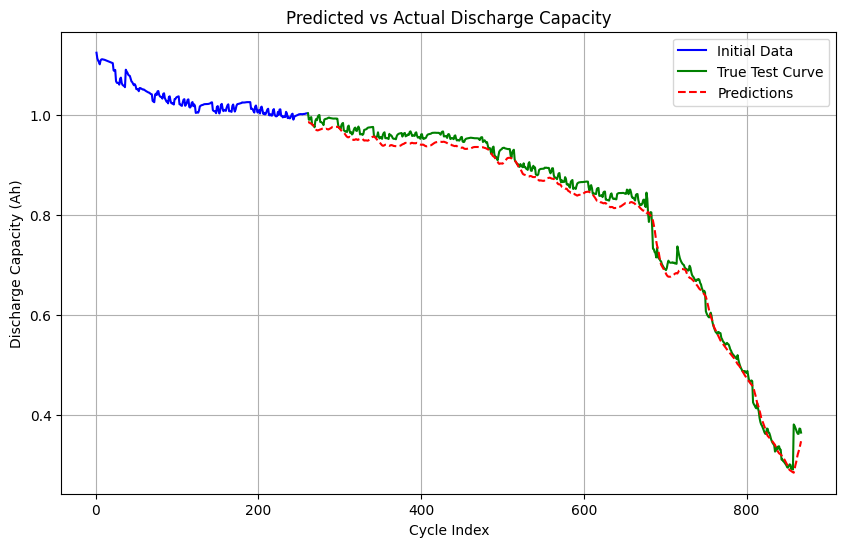

In [28]:
plot_predictions(model_3, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 1, 30)

## CNN - DBLSTM Model

In [22]:
model_4 = CNN_DBLSTM_Model([24, 48, 72], 128, 4).to(device)
optimizer = torch.optim.Adam(model_4.parameters())
criterion = torch.nn.MSELoss()
EPOCHS = 10


for epoch in range(EPOCHS):
    epoch_loss = 0.0
    model_4.train()
    
    for x, y in train_dataloader:
        loss_item = train_step(model_4, x.unsqueeze(1), y, optimizer, criterion, device, MIN, DIFF)
        epoch_loss += loss_item

    avg_loss = epoch_loss / len(train_dataloader)
    if epoch%1 == 0:
        print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss}")

Epoch 1/10, Loss: 0.034260635264217854
Epoch 2/10, Loss: 0.0015800660847752304
Epoch 3/10, Loss: 0.0008059571594679477
Epoch 4/10, Loss: 0.0017084452985137752
Epoch 5/10, Loss: 0.0006520233245454792
Epoch 6/10, Loss: 0.0005746851921021762
Epoch 7/10, Loss: 0.0007945413297518924
Epoch 8/10, Loss: 0.0005224056071342233
Epoch 9/10, Loss: 0.000506785972853273
Epoch 10/10, Loss: 0.0003965916899146946


In [23]:
model_4.eval()

test_loss = 0.0
criterion = torch.nn.MSELoss(reduction='sum')

with torch.no_grad():
    for x, y in test_dataloader:
        test_loss += test_step(model_4, x.unsqueeze(1), y, criterion, device, MIN, DIFF)

test_loss = np.sqrt(test_loss)
avg_test_loss = test_loss / (len(test_dataloader)*32)
print(len(test_dataloader))

print(f"RMSE: {avg_test_loss:}")

27
RMSE: 0.0003657131624361173


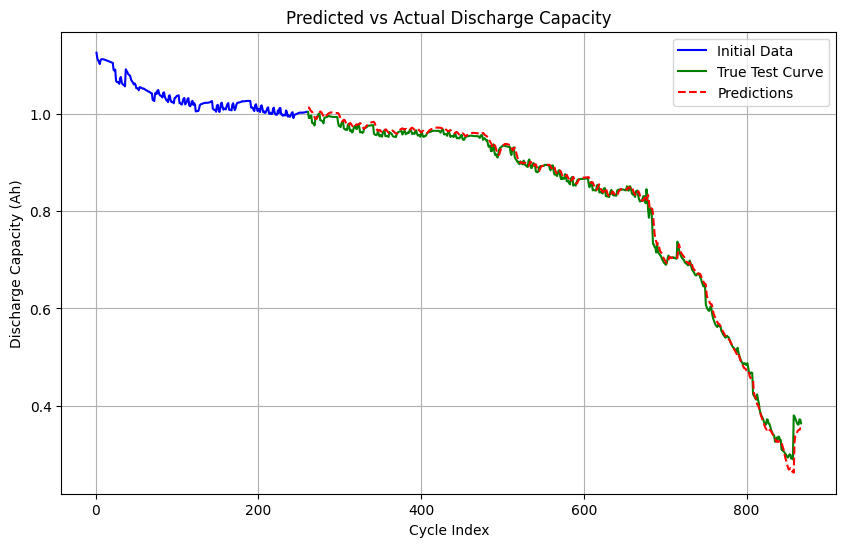

In [24]:
plot_predictions(model_4, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 1, 30)